In [1]:
import sys
sys.path.insert(0,'../g3algo/')
from center_binned_stats import center_binned_stats as cbs
import numpy as np
import pandas as pd
import matplotlib
#matplotlib.use('TkAgg')
import matplotlib.pyplot as plt
from smoothedbootstrap import smoothedbootstrap as sbs

goals
- validate ECO HI inventory (relation matches for RESOLVE and ECO given systematic errors)
- measure shape and scatter of the relation
- validate group finder
    - show matches FoF
- compare with literature
    - possibly validate group finder, otherwise explain discrepancy

need to do:
- decide bins for HIHM relation
- for each bin and for each of RESOLVE and ECO:
    - get median group HI value
    - get statistical error on it from bootstrapping
    - estimate systematic error from ECO (for resolve) or from mocks (ECO)
- output all that file
- show plot with scatter
- show plot with median relation + statistical error (bootstrap) + systematic error (cosmic var)
- show plot comparing to previous results

## Compute $M_{\rm HI\,grp}-M_{\rm halo}$ Relation for RESOLVE

In [2]:
resolve=pd.read_csv("../resolve_and_eco/RESOLVEdata_G3catalog_luminosity.csv")
resolve.loc[:,'abovefloor']=((resolve.f_a==1)&(resolve.absrmag<=-17.33))|((resolve.f_b==1)&(resolve.absrmag<=-17.0))
resolve=resolve[(resolve.g3grpcz_l>=4500)&(resolve.g3grpcz_l<=7000)&(resolve.abovefloor)&(resolve.g3fc_l==1)]
eco=pd.read_csv("../resolve_and_eco/ECOdata_G3catalog_luminosity.csv")
eco=eco[(eco.g3grpcz_l>3000)&(eco.g3grpcz_l<7000)&(eco.absrmag<=-17.33)&(eco.g3fc_l==1)&(eco.resname=='notinresolve')]

/tmp/ipykernel_785517/2354615653.py:4: DtypeWarning: Columns (70,83) have mixed types. Specify dtype option on import or set low_memory=False.
  eco=pd.read_csv("../resolve_and_eco/ECOdata_G3catalog_luminosity.csv")


In [3]:
binvalues = [11,11.1,11.2,11.3,11.4,11.5,11.6,11.7,11.95,12.2,12.45,12.7,12.95,13.3,14.75]
binvalues = [11,11.15,11.3,11.45,11.6,11.75,12.,12.25,12.5,12.75,12.95,13.3,14.75]
#binvalues = [11,11.15,11.3,11.45,11.6,11.75,12.,12.25,12.5,12.75,12.95,13.3,13.8,14.75]

In [4]:
resgrpmhi = resolve.g3grpmhi_l.to_numpy()
reslogmh = resolve.g3logmh_l.to_numpy()
# dyn=resolve.g3logmhdyn_l.to_numpy()
# gN=(resolve.g3grpngi_l+resolve.g3grpndw_l).to_numpy()
# reslogmh[gN>7]=dyn[gN>7]
resfrac = np.log10(10**resgrpmhi / 10**reslogmh)

In [5]:
# medians
resmediangrpmhi,bincenters,_,_=cbs(reslogmh,resgrpmhi,'median',bins=binvalues)
resmedianfrac,bincenters,_,_=cbs(reslogmh,resfrac,'median',bins=binvalues)
# statistical error on median
resmediangrpmhi_m1sig = np.zeros_like(resmediangrpmhi)
resmediangrpmhi_p1sig = np.zeros_like(resmediangrpmhi)
resmedianfrac_m1sig = np.zeros_like(resmedianfrac)
resmedianfrac_p1sig = np.zeros_like(resmedianfrac)
for ii in range(0,len(binvalues)-1):
    datasel = np.where((reslogmh>binvalues[ii])&(reslogmh<binvalues[ii+1]))
    dist_of_medians = sbs(resgrpmhi[datasel], 5000, lambda x: np.median(x,axis=1))
    ptiles = np.percentile(dist_of_medians, (16,84))
    resmediangrpmhi_m1sig[ii]=ptiles[0]
    resmediangrpmhi_p1sig[ii]=ptiles[1]
    dist_of_medians2 = sbs(resfrac[datasel],5000,lambda x:np.median(x,axis=1))
    ptiles2 = np.percentile(dist_of_medians2, (16,84))
    resmedianfrac_m1sig[ii]=ptiles2[0]
    resmedianfrac_p1sig[ii]=ptiles2[1]
resmediangrpmhi_m1sig =  resmediangrpmhi - resmediangrpmhi_m1sig
resmediangrpmhi_p1sig = -resmediangrpmhi + resmediangrpmhi_p1sig
resmedianfrac_m1sig = resmedianfrac - resmedianfrac_m1sig
resmedianfrac_p1sig = -resmedianfrac + resmedianfrac_p1sig

Next we need to estimate the systematic error on each bin's $M_{\rm HI,\,grp}$ median for RESOLVE. This can be computed by breaking up ECO into many RESOLVE-sized chunks and looking at the spread in the distribution of $M_{\rm HI\,grp}$ values from the chunks.

First note that, according to E16, ECO's volume (no buffer) is 151829 (Mpc/h)$^3$ and the sum of RESOLVE's volume (A and B) = 13172.384 (Mpc/h)$^3$ + 4709.837 (Mpc/h)$^3$ = 17882 (Mpc/h)$^3$. That means RESOLVE can fit into ECO 10.7 times.

To split it into 10 RESOLVE-sized chunks, we can break up ECO into 5 10-degree chunks along its declination range and 2 53.5-degree chunks along its RA range.

In [6]:
ecochunks=[]
chunkRAlimits=[130,183.5,237]
chunkDeclimits=[-1,10,20,30,40,50]
chunkRAranges=[]
chunkDecranges=[]
for ii in range(0,len(chunkRAlimits)-1):
    for jj in range(0,len(chunkDeclimits)-1):
        chunkRAranges.append((chunkRAlimits[ii],chunkRAlimits[ii+1]))
        chunkDecranges.append((chunkDeclimits[jj],chunkDeclimits[jj+1]))
for ii in range(0,(len(chunkRAlimits)-1)*(len(chunkDeclimits)-1)):
    tmp=eco[(eco.g3grpcz_l>3000)&(eco.g3grpcz_l<7000)&(eco.radeg>chunkRAranges[ii][0])\
            &(eco.radeg<chunkRAranges[ii][1])\
            &(eco.dedeg>chunkDecranges[ii][0])\
            &(eco.dedeg<chunkDecranges[ii][1])]
    ecochunks.append(tmp)
assert len(ecochunks)==(len(chunkRAlimits)-1)*(len(chunkDeclimits)-1)

Now what we want to do is process each chunk. For each bin, we need to go through each chunk and get the distribution of medians. The 1sigma confidence interval on the median of each distribution can be the estimate of the systematic error.

In [7]:
mediangrpmhi_from_chk=[]
medianfrac_from_chk=[]
for chk in ecochunks:
    tmp,_,_,_ = cbs(chk.g3logmh_l.to_numpy(),chk.g3grpmhi_l.to_numpy(),'median',bins=binvalues)
    mediangrpmhi_from_chk.append(tmp)
    tmp2,_,_,_= cbs(chk.g3logmh_l.to_numpy(),np.log10(10**chk.g3grpmhi_l.to_numpy()/10**chk.g3logmh_l.to_numpy()),'median',bins=binvalues)
    medianfrac_from_chk.append(tmp2)
mediangrpmhi_from_chk=np.array(mediangrpmhi_from_chk)
medianfrac_from_chk=np.array(medianfrac_from_chk)

In [8]:
resmediangrpmhi_msys = np.nanmedian(mediangrpmhi_from_chk,axis=0)-np.nanpercentile(mediangrpmhi_from_chk,16,axis=0)
resmediangrpmhi_psys = -1*np.nanmedian(mediangrpmhi_from_chk,axis=0)+np.nanpercentile(mediangrpmhi_from_chk,84,axis=0)

In [9]:
resmedianfrac_msys = np.nanmedian(medianfrac_from_chk,axis=0)-np.nanpercentile(medianfrac_from_chk,16,axis=0)
resmedianfrac_psys = -1*np.nanmedian(medianfrac_from_chk,axis=0)+np.nanpercentile(medianfrac_from_chk,84,axis=0)

In [10]:
resmedianfrac_msys, resmedianfrac_psys

(array([0.04815914, 0.01528586, 0.07985862, 0.08436548, 0.05690241,
        0.09388607, 0.08472179, 0.13436382, 0.17475554, 0.1837938 ,
        0.06937328, 0.18989344]),
 array([0.08259692, 0.05176136, 0.03078075, 0.05503763, 0.06894889,
        0.12418464, 0.07487881, 0.20848169, 0.22713499, 0.28721849,
        0.14220819, 0.20445951]))

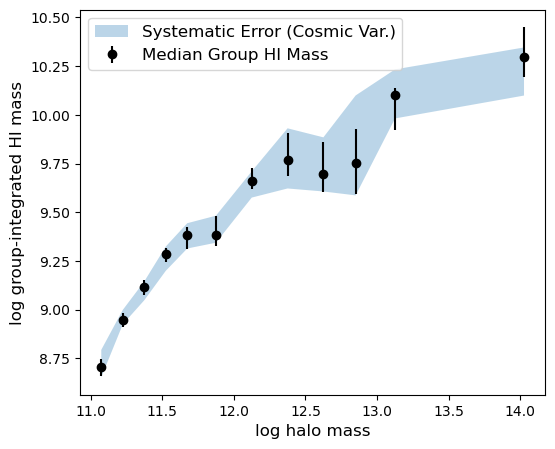

In [11]:
%matplotlib inline
plt.figure(figsize=(6,5))
plt.fill_between(bincenters,resmediangrpmhi-resmediangrpmhi_msys,resmediangrpmhi+resmediangrpmhi_psys, alpha=0.3,label='Systematic Error (Cosmic Var.)')
plt.errorbar(bincenters,resmediangrpmhi,yerr=[resmediangrpmhi_m1sig,resmediangrpmhi_p1sig],ls='none', marker='o',color='k', label='Median Group HI Mass')
plt.xlabel("log halo mass",fontsize=12)
plt.ylabel("log group-integrated HI mass",fontsize=12)
plt.legend(loc='upper left',fontsize=12)
plt.show()

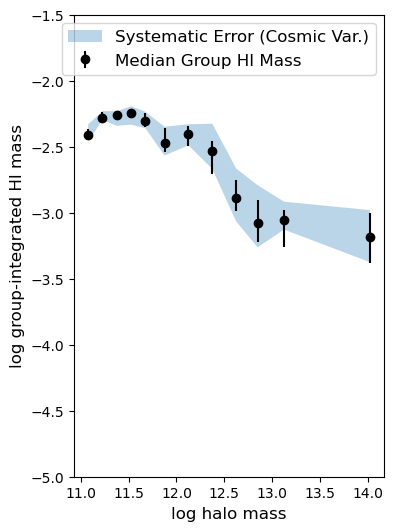

In [12]:
plt.figure(figsize=(4,6))
plt.fill_between(bincenters,resmedianfrac-resmedianfrac_msys,resmedianfrac+resmedianfrac_psys, alpha=0.3,label='Systematic Error (Cosmic Var.)')
plt.errorbar(bincenters,resmedianfrac,yerr=[resmedianfrac_m1sig,resmedianfrac_p1sig],ls='none', marker='o',color='k', label='Median Group HI Mass')
plt.xlabel("log halo mass",fontsize=12)
plt.ylabel("log group-integrated HI mass",fontsize=12)
plt.legend(loc='best',fontsize=12)
plt.ylim(-5,-1.5)
plt.show()

## Compute $M_{\rm HI\,grp}-M_{\rm halo}$ Relation for ECO

Now we are going to do a similar process but for ECO (excluding RESOLVE-A). This time, we'll use mocks to estimate systematic errors from cosmic variance.

In [13]:
ecogrpmhi = eco.g3grpmhi_l.to_numpy()
ecologmh = eco.g3logmh_l.to_numpy()
# dyn=eco.g3logmhdyn_l.to_numpy()
# gN=(eco.g3grpngi_l+eco.g3grpndw_l).to_numpy()
# ecologmh[gN>7]=dyn[gN>7]
ecofrac = np.log10(10**ecogrpmhi / 10**ecologmh)

In [14]:
# medians
ecomediangrpmhi,bincenters,_,_=cbs(ecologmh,ecogrpmhi,np.median,bins=binvalues)
# statistical error on median
ecomediangrpmhi_m1sig = np.zeros_like(ecomediangrpmhi)
ecomediangrpmhi_p1sig = np.zeros_like(ecomediangrpmhi)
for ii in range(0,len(binvalues)-1):
    datasel = np.where((ecologmh>binvalues[ii])&(ecologmh<binvalues[ii+1]))
    dist_of_medians = sbs(ecogrpmhi[datasel], 5000, lambda x: np.median(x,axis=1))
    ptiles = np.percentile(dist_of_medians, (16,84))
    ecomediangrpmhi_m1sig[ii]=ptiles[0]
    ecomediangrpmhi_p1sig[ii]=ptiles[1]
ecomediangrpmhi_m1sig =  ecomediangrpmhi - ecomediangrpmhi_m1sig
ecomediangrpmhi_p1sig = -ecomediangrpmhi + ecomediangrpmhi_p1sig

In [15]:
# medians
ecomedianfrac,bincenters,_,_=cbs(ecologmh,ecofrac,'median',bins=binvalues)
# statistical error on median
ecomedianfrac_m1sig = np.zeros_like(ecomedianfrac)
ecomedianfrac_p1sig = np.zeros_like(ecomedianfrac)
for ii in range(0,len(binvalues)-1):
    datasel = np.where((ecologmh>binvalues[ii])&(ecologmh<binvalues[ii+1]))
    dist_of_medians = sbs(ecofrac[datasel], 5000, lambda x: np.median(x,axis=1))
    ptiles = np.percentile(dist_of_medians, (16,84))
    ecomedianfrac_m1sig[ii]=ptiles[0]
    ecomedianfrac_p1sig[ii]=ptiles[1]
ecomedianfrac_m1sig =  ecomedianfrac - ecomedianfrac_m1sig
ecomedianfrac_p1sig = -ecomedianfrac + ecomedianfrac_p1sig

Before moving on, let's quickly check our answer for the most massive bin. We can compare our answer with a manual bootstrapping from np.random.choice.

In [16]:
# 13.3,14.75
tmp = ecogrpmhi[np.where(np.logical_and(ecologmh>binvalues[-2],ecologmh<binvalues[-1]))]
newmedians=[]
for ii in range(0,5000):
    newmedians.append(np.median(np.random.choice(tmp,size=len(tmp))))
print('these should be similar (order-of-magnitude): ')
print(ecomediangrpmhi_p1sig[-1], np.std(newmedians))

these should be similar (order-of-magnitude): 
0.02566108586466065 0.03620188689599153


In [17]:
# 13.3,14.75
tmp = ecofrac[np.where(np.logical_and(ecologmh>binvalues[-2],ecologmh<binvalues[-1]))]
newmedians=[]
for ii in range(0,5000):
    newmedians.append(np.median(np.random.choice(tmp,size=len(tmp))))
print('these should be similar (order-of-magnitude): ')
print(ecomedianfrac_p1sig[-1], np.std(newmedians))

these should be similar (order-of-magnitude): 
0.05099781191576502 0.06138229686148815


With that checked, we can move on to computing systematic errors for group $M_{\rm HI}$ for ECO. The errors will be computed from the mock catalogs.

As we did before using chunks, we will go through each mock catalog and attain the median $M_{\rm HI\,grp}$ for every bin in accordance with `binvalues`. For each of these halo mass bins, ECO's systematic error will be the 1$\sigma$ confidence interval on the distribution of median values.

**NOTE:** Make sure group finding on mocks is up-to-date before running the below cells.

In [18]:
import os

In [19]:
mocks = [pd.read_csv('../halobiasgroupcats/fiducial/'+str(x)) for x in os.listdir('../halobiasgroupcats/fiducial/')]

Now we've loaded up the mocks that we need to compute our systematic cosmic variance error. The following cell iterates through each of these mocks and computes the median group HI mass in each of bins corresponding to `binvalues`.

In [20]:
mockgrpmhimedians=[]
mockfracmedians=[]
for catl in mocks:
    tmp=catl[catl.g3grp_l>0]
    tmp=tmp.groupby('g3grp_l').first()
    logmh=tmp.g3logmh_l.to_numpy()
    mhigrp=(tmp.g3grpmhi_l.to_numpy())
    frac = np.log10(10**mhigrp / 10**logmh)
    median,_,_,_=cbs(logmh,mhigrp,'median',bins=binvalues)
    mockgrpmhimedians.append(median)
    median,_,_,_=cbs(logmh,frac,'median',bins=binvalues)
    mockfracmedians.append(median)
mockgrpmhimedians=np.array(mockgrpmhimedians)
mockfracmedians=np.array(mockfracmedians)

In [21]:
np.nanmedian(mockgrpmhimedians,axis=0).shape

(12,)

In [22]:
ecomediangrpmhi_msys = np.nanmedian(mockgrpmhimedians,axis=0)-np.nanpercentile(mockgrpmhimedians,16,axis=0)
ecomediangrpmhi_psys = -1*np.nanmedian(mockgrpmhimedians,axis=0)+np.nanpercentile(mockgrpmhimedians,84,axis=0)

In [23]:
ecomedianfrac_msys = np.nanmedian(mockfracmedians,axis=0)-np.nanpercentile(mockfracmedians,16,axis=0)
ecomedianfrac_psys = -1*np.nanmedian(mockfracmedians,axis=0)+np.nanpercentile(mockfracmedians,84,axis=0)

In [24]:
ecomediangrpmhi_msys, ecomediangrpmhi_psys

(array([0.03760014, 0.09759978, 0.09230516, 0.08999995, 0.08279986,
        0.03452088, 0.12817503, 0.05296636, 0.0913943 , 0.10605292,
        0.13845421, 0.06383588]),
 array([0.13760022, 0.11520022, 0.11809467, 0.10999995, 0.0875996 ,
        0.05727584, 0.12222354, 0.0898558 , 0.10949111, 0.08160926,
        0.05856542, 0.12832107]))

In [25]:
ecomedianfrac_msys, ecomedianfrac_psys

(array([0.07536049, 0.10009011, 0.0886894 , 0.08169199, 0.1045211 ,
        0.02830632, 0.11483524, 0.05953176, 0.07097311, 0.09334733,
        0.16559753, 0.12387993]),
 array([0.13897944, 0.11111163, 0.1250592 , 0.11303744, 0.07302963,
        0.02425982, 0.13884072, 0.07930232, 0.15752098, 0.09230471,
        0.08700254, 0.08774853]))

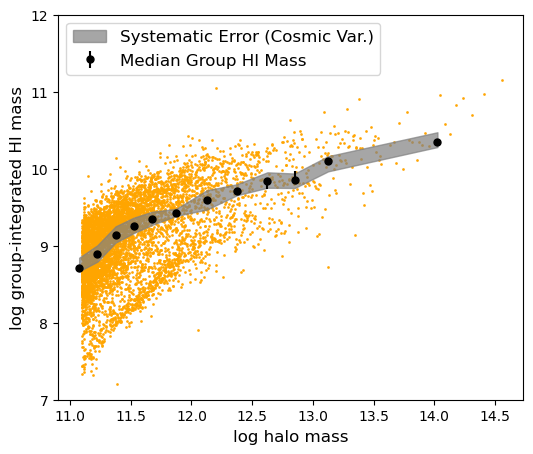

In [26]:
plt.figure(figsize=(6,5))
plt.plot(ecologmh,ecogrpmhi,'.', color='orange',alpha=0.9, zorder=0, markersize=2)
plt.errorbar(bincenters,ecomediangrpmhi,yerr=[ecomediangrpmhi_m1sig,ecomediangrpmhi_p1sig],ls='none', marker='o', markersize=5, color='k', label='Median Group HI Mass')
plt.fill_between(bincenters,ecomediangrpmhi-ecomediangrpmhi_msys,ecomediangrpmhi+ecomediangrpmhi_psys, color='gray', alpha=0.7,label='Systematic Error (Cosmic Var.)')
plt.xlabel("log halo mass",fontsize=12)
plt.ylabel("log group-integrated HI mass",fontsize=12)
plt.legend(loc='upper left',fontsize=12)
plt.ylim(7,12)
plt.show()

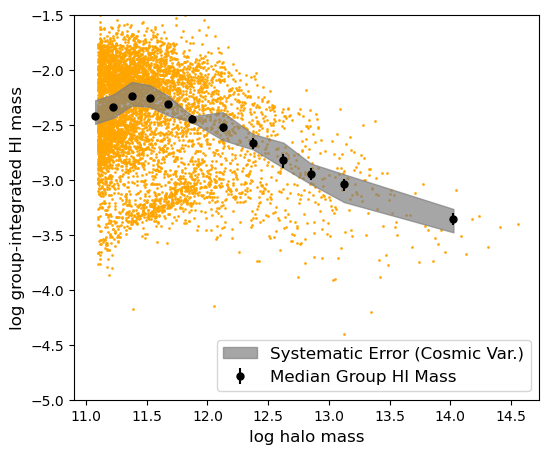

In [27]:
plt.figure(figsize=(6,5))
plt.plot(ecologmh,ecofrac,'.', color='orange',alpha=0.9, zorder=0, markersize=2)
plt.errorbar(bincenters,ecomedianfrac,yerr=[ecomedianfrac_m1sig,ecomedianfrac_p1sig],ls='none', marker='o', markersize=5, color='k', label='Median Group HI Mass')
plt.fill_between(bincenters,ecomedianfrac-ecomedianfrac_msys,ecomedianfrac+ecomedianfrac_psys, color='gray', alpha=0.7,label='Systematic Error (Cosmic Var.)')
plt.xlabel("log halo mass",fontsize=12)
plt.ylabel("log group-integrated HI mass",fontsize=12)
plt.legend(loc='lower right',fontsize=12)
plt.ylim(-5,-1.5)
plt.show()

In [28]:
# get Mstar, Mbary medians also
ecogrpmstar = eco.g3grplogS_l.to_numpy()
ecogrpmbary = eco.g3grplogB_l.to_numpy()
ecostellarfrac = np.log10(10**ecogrpmstar/10**ecologmh)
ecobaryfrac = np.log10(10**ecogrpmbary/10**ecologmh)
ecomediangrpmstar,_,_,_=cbs(ecologmh,ecogrpmstar,'median',bins=binvalues)
ecomediangrpmbary,_,_,_=cbs(ecologmh,ecogrpmbary,'median',bins=binvalues)
# ecogrpstellarfrac=np.log10(10**ecomediangrpmstar / 10**bincenters)
# ecogrpbaryonicfrac=np.log10(10**ecomediangrpmbary / 10**bincenters)

In [29]:
# medians
ecomedianbaryfrac,bincenters,_,_=cbs(ecologmh,ecobaryfrac,'median',bins=binvalues)
# statistical error on median
ecomedianbaryfrac_m1sig = np.zeros_like(ecomedianbaryfrac)
ecomedianbaryfrac_p1sig = np.zeros_like(ecomedianbaryfrac)
for ii in range(0,len(binvalues)-1):
    datasel = np.where((ecologmh>binvalues[ii])&(ecologmh<binvalues[ii+1]))
    dist_of_medians = sbs(ecobaryfrac[datasel], 5000, lambda x: np.median(x,axis=1))
    ptiles = np.percentile(dist_of_medians, (16,84))
    ecomedianbaryfrac_m1sig[ii]=ptiles[0]
    ecomedianbaryfrac_p1sig[ii]=ptiles[1]
ecomedianbaryfrac_m1sig =  ecomedianbaryfrac - ecomedianbaryfrac_m1sig
ecomedianbaryfrac_p1sig = -ecomedianbaryfrac + ecomedianbaryfrac_p1sig

In [30]:
# medians
ecomedianstellarfrac,bincenters,_,_=cbs(ecologmh,ecostellarfrac,'median',bins=binvalues)
# statistical error on median
ecomedianstellarfrac_m1sig = np.zeros_like(ecomedianstellarfrac)
ecomedianstellarfrac_p1sig = np.zeros_like(ecomedianstellarfrac)
for ii in range(0,len(binvalues)-1):
    datasel = np.where((ecologmh>binvalues[ii])&(ecologmh<binvalues[ii+1]))
    dist_of_medians = sbs(ecostellarfrac[datasel], 5000, lambda x: np.median(x,axis=1))
    ptiles = np.percentile(dist_of_medians, (16,84))
    ecomedianstellarfrac_m1sig[ii]=ptiles[0]
    ecomedianstellarfrac_p1sig[ii]=ptiles[1]
ecomedianstellarfrac_m1sig =  ecomedianstellarfrac - ecomedianstellarfrac_m1sig
ecomedianstellarfrac_p1sig = -ecomedianstellarfrac + ecomedianstellarfrac_p1sig

In [31]:
outputdata = np.array([
    bincenters,
    resmediangrpmhi,
    resmediangrpmhi_m1sig,
    resmediangrpmhi_p1sig,
    resmediangrpmhi_msys,
    resmediangrpmhi_psys,
    ecomediangrpmhi,
    ecomediangrpmhi_m1sig,
    ecomediangrpmhi_p1sig,
    ecomediangrpmhi_msys,
    ecomediangrpmhi_psys,
    ecomediangrpmstar,
    ecomediangrpmbary,
])
pd.DataFrame(outputdata.T, columns=['logmh','resmhigrp','resmhigrp_staterrlo','resmhigrp_staterrhi',\
            'resmhigrp_syserrlo','resmhigrp_syserrhi','ecomhigrp','ecomhigrp_staterrlo','ecomhigrp_staterrhi',\
            'ecomhigrp_syserrlo','ecomhigrp_syserrhi','ecogrpmstar',\
            'ecogrpmbary']).to_csv("resolve_eco_hihm_updated052023.csv",index=False)

In [32]:
outputdata = np.array([
    bincenters,
    resmedianfrac,
    resmedianfrac_m1sig,
    resmedianfrac_p1sig,
    resmedianfrac_msys,
    resmedianfrac_psys,
    ecomedianfrac,
    ecomedianfrac_m1sig,
    ecomedianfrac_p1sig,
    ecomedianfrac_msys,
    ecomedianfrac_psys,
    ecomedianstellarfrac,
    ecomedianstellarfrac_m1sig,
    ecomedianstellarfrac_p1sig,
    ecomedianbaryfrac,
    ecomedianbaryfrac_m1sig,
    ecomedianbaryfrac_p1sig
])
pd.DataFrame(outputdata.T, columns=['logmh','resfrac','resfrac_staterrlo','resfrac_staterrhi',\
            'resfrac_syserrlo','resfrac_syserrhi','ecofrac','ecofrac_staterrlo','ecofrac_staterrhi',\
            'ecofrac_syserrlo','ecofrac_syserrhi','ecostellarfrac','ecostellarfrac_staterrlo',\
            'ecostellarfrac_staterrhi','ecobaryfrac','ecobaryfrac_staterrlo','ecobaryfrac_staterrhi']).to_csv("resolve_eco_mhiovermhalo_updated052023.csv",index=False)

In [33]:
%reset -f

# Paper Plots

In [34]:
def hihalomodel(Mh, M0, Mmin, alpha):
    return M0*((Mh/Mmin)**alpha)*np.exp(-1*Mmin/Mh)
def hihalomodel2(params, Mh):
    return params[0]*((Mh/params[1])**params[2])*np.exp(-1*params[1]/Mh)

In [35]:
import sys
sys.path.insert(0,'../g3algo/')
import numpy as np
import pandas as pd
import matplotlib
#matplotlib.use('TkAgg')
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, AutoLocator
from matplotlib import rcParams
from scipy.optimize import curve_fit
from scipy.stats import chisquare
import foftools as fof
import iterativecombination as ic
from scipy import odr
from seaborn import kdeplot
rcParams['axes.labelsize'] = 9
rcParams['xtick.labelsize'] = 9
rcParams['ytick.labelsize'] = 9
rcParams['legend.fontsize'] = 9
rcParams['font.family'] = 'sans-serif'
rcParams['grid.color'] = 'k'
rcParams['grid.linewidth'] = 0.2
my_locator = MaxNLocator(6)
singlecolsize = (3.3522420091324205, 2.0717995001590714)
doublecolsize = (7.500005949910059, 4.3880449973709)

In [36]:
resolve=pd.read_csv("../resolve_and_eco/RESOLVEdata_G3catalog_luminosity.csv")
resolve.loc[:,'abovefloor']=((resolve.f_a==1)&(resolve.absrmag<=-17.33))|((resolve.f_b==1)&(resolve.absrmag<=-17.0))
resolve=resolve[(resolve.g3grpcz_l>4500)&(resolve.g3grpcz_l<7000)&(resolve.abovefloor)&(resolve.g3fc_l==1)]
eco=pd.read_csv("../resolve_and_eco/ECOdata_G3catalog_luminosity.csv")
eco=eco[(eco.g3grpcz_l>3000)&(eco.g3grpcz_l<7000)&(eco.absrmag<-17.33)&(eco.g3fc_l==1)&(eco.resname=='notinresolve')]
binnedhihm = pd.read_csv("resolve_eco_hihm_updated052023.csv")
binnedfrac = pd.read_csv("resolve_eco_mhiovermhalo_updated052023.csv")

/tmp/ipykernel_785517/2415006015.py:4: DtypeWarning: Columns (70,83) have mixed types. Specify dtype option on import or set low_memory=False.
  eco=pd.read_csv("../resolve_and_eco/ECOdata_G3catalog_luminosity.csv")


## (1) The Shape of the RESOLVE and ECO HI-halo Mass Relation

In [37]:
%matplotlib inline
resolveshadecolor='#7AA8E7'
resolvemarkercolor='#3D5473'
ecoshadecolor='#E7B97A'
ecomarkercolor='#a66d1e'

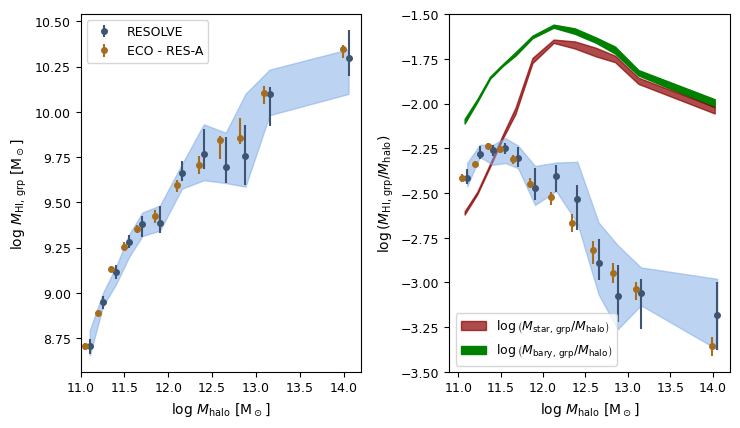

In [38]:
hoffset = 0.03
fig,axs=plt.subplots(figsize=doublecolsize,ncols=2)
axs[0].errorbar(binnedhihm.logmh+hoffset,binnedhihm.resmhigrp,\
                yerr=[binnedhihm.resmhigrp_staterrlo,binnedhihm.resmhigrp_staterrhi],\
                color=resolvemarkercolor,ls='none',markersize=4, marker='o', label='RESOLVE')
axs[0].fill_between(binnedhihm.logmh+hoffset,binnedhihm.resmhigrp-binnedhihm.resmhigrp_syserrlo,\
                    binnedhihm.resmhigrp_syserrhi+binnedhihm.resmhigrp,\
                   color=resolveshadecolor, alpha=0.5)
axs[0].errorbar(binnedhihm.logmh-hoffset,binnedhihm.ecomhigrp,\
                yerr=[binnedhihm.ecomhigrp_staterrlo,binnedhihm.ecomhigrp_staterrhi],\
                color=ecomarkercolor,ls='none',markersize=4, marker='o', label='ECO - RES-A')
# axs[0].fill_between(binnedhihm.logmh-hoffset,binnedhihm.ecomhigrp-binnedhihm.ecomhigrp_syserrlo,\
#                     binnedhihm.ecomhigrp_syserrhi+binnedhihm.ecomhigrp,\
#                    color=ecoshadecolor, alpha=0.7)
axs[0].legend(loc='best')

#axs[1].plot(binnedfrac.logmh,binnedfrac.ecostellarfrac,'r-',label=r"$\log \left( M_{\rm star,\, grp} / M_{\rm halo}  \right)$",zorder=1)
axs[1].fill_between(binnedfrac.logmh,binnedfrac.ecostellarfrac-binnedfrac.ecostellarfrac_staterrlo,\
                   binnedfrac.ecostellarfrac+binnedfrac.ecostellarfrac_staterrhi,color='darkred',zorder=1,\
                    label=r"$\log \left( M_{\rm star,\, grp} / M_{\rm halo}  \right)$",alpha=0.7)
#axs[1].plot(binnedfrac.logmh,binnedfrac.ecobaryfrac,'k--',label=r"$\log \left( M_{\rm bary,\, grp} / M_{\rm halo}  \right)$")
# axs[1].errorbar(binnedfrac.logmh,binnedfrac.ecobaryfrac,\
#                 yerr=[2*binnedfrac.ecobaryfrac_staterrlo,2*binnedfrac.ecobaryfrac_staterrhi],\
#                linestyle='None',marker='o',color='green',markersize=4, label=r"$\log \left( M_{\rm bary,\, grp} / M_{\rm halo}  \right)$")
axs[1].fill_between(binnedfrac.logmh,binnedfrac.ecobaryfrac-binnedfrac.ecobaryfrac_staterrlo,\
                   binnedfrac.ecobaryfrac+binnedfrac.ecobaryfrac_staterrhi,color='green',zorder=0,\
                    label=r"$\log \left( M_{\rm bary,\, grp} / M_{\rm halo}  \right)$")
axs[1].errorbar(binnedfrac.logmh+hoffset,binnedfrac.resfrac,\
                yerr=[binnedfrac.resfrac_staterrlo,binnedfrac.resfrac_staterrhi],\
                color=resolvemarkercolor,ls='none',markersize=4, marker='o')
axs[1].fill_between(binnedfrac.logmh+hoffset,binnedfrac.resfrac-binnedfrac.resfrac_syserrlo,\
                    binnedfrac.resfrac_syserrhi+binnedfrac.resfrac,\
                   color=resolveshadecolor, alpha=0.5)
axs[1].errorbar(binnedfrac.logmh-hoffset,binnedfrac.ecofrac,\
                yerr=[binnedfrac.ecofrac_staterrlo,binnedfrac.ecofrac_staterrhi],\
                color=ecomarkercolor,ls='none',markersize=4, marker='o')
# axs[1].fill_between(binnedfrac.logmh-hoffset,binnedfrac.ecofrac-binnedfrac.ecofrac_syserrlo,\
#                     binnedfrac.ecofrac_syserrhi+binnedfrac.ecofrac,\
#                    color=ecoshadecolor, alpha=0.7)
axs[1].set_ylim(-3.5,-1.5)
axs[1].legend(loc='lower left')


axs[0].set_ylabel(r"log $M_{\rm HI,\, grp}$ [$\rm M_\odot$]")
axs[0].set_xlabel(r"log $M_{\rm halo}$ [$\rm M_\odot$]")
axs[1].set_xlabel(r"log $M_{\rm halo}$ [$\rm M_\odot$]")
axs[1].set_ylabel(r"$\log \left( M_{\rm HI,\, grp} / M_{\rm halo}  \right)$")
axs[0].set_xlim(11,14.2)
#axs[0].xaxis.set_minor_locator(MaxNLocator(5))
plt.tight_layout()
plt.savefig("../figures/RESOLVE_ECO_HIHMshape.pdf")
plt.show()

### The Best-Fitting Halo Model

In [39]:
staterr = (binnedhihm.ecomhigrp_staterrlo+binnedhihm.ecomhigrp_staterrhi)/2.
syserr = (binnedhihm.ecomhigrp_syserrlo+binnedhihm.ecomhigrp_syserrhi)/2.
comberr = staterr#+syserr
comberrlin = 10**binnedhihm.ecomhigrp-10**(binnedhihm.ecomhigrp-comberr)
popthi,pcov=curve_fit(hihalomodel, 10**binnedhihm.logmh, 10**binnedhihm.ecomhigrp,\
                     sigma=comberrlin, absolute_sigma=True, p0=[1.689e9, 1.2698e11, 3.686e-1], maxfev=2000)
perrhi=np.sqrt(np.diagonal(pcov))

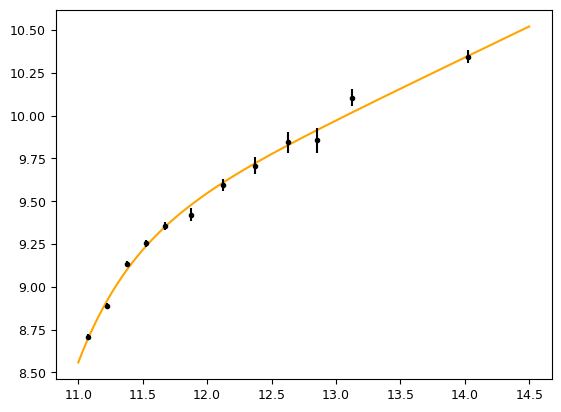

In [40]:
plt.figure()
tx = np.linspace(11,14.5,int(5e5))
plt.plot(tx, np.log10(hihalomodel(10**tx,*popthi)),color='orange')
plt.errorbar(binnedhihm.logmh,binnedhihm.ecomhigrp,yerr=staterr,ls='None',color='k',marker='.')
plt.show()

In [41]:
print("best fitting logM0: ", np.log10(popthi[0]), " +/- ", np.log10(popthi[0])-np.log10(perrhi[0]))
print("best fitting logMmin: ", np.log10(popthi[1]), " +/- ", np.log10(popthi[1])-np.log10(perrhi[1]))
print("best fitting alpha: ", popthi[2], " +/- ", perrhi[2])

best fitting logM0:  9.32905350355286  +/-  1.0946801057173374
best fitting logMmin:  11.20555292992538  +/-  1.1955983778619999
best fitting alpha:  0.3619968680890722  +/-  0.017762079068122293


In [42]:
# Now fit FOF
ecofof=pd.read_csv("../resolve_and_eco/ECOdata_G3catalog_luminosity.csv")
fofmhigrp = ic.get_int_mass(np.log10(10**ecofof.logmgas/1.4),ecofof.fofgrp)
ecofof.loc[:,'fofmhigrp']=fofmhigrp
ecofof=ecofof[(ecofof.fofgrpcz>3000)&(ecofof.fofgrpcz<7000)&(ecofof.absrmag<-17.33)&(ecofof.fc==1)&(ecofof.resname=='notinresolve')]
fofmhigrp = ecofof.fofmhigrp.to_numpy()
foflogmh = ecofof.foflogmhvir.to_numpy()

/tmp/ipykernel_785517/2061153014.py:2: DtypeWarning: Columns (70,83) have mixed types. Specify dtype option on import or set low_memory=False.
  ecofof=pd.read_csv("../resolve_and_eco/ECOdata_G3catalog_luminosity.csv")


In [43]:
from center_binned_stats import center_binned_stats as cbs

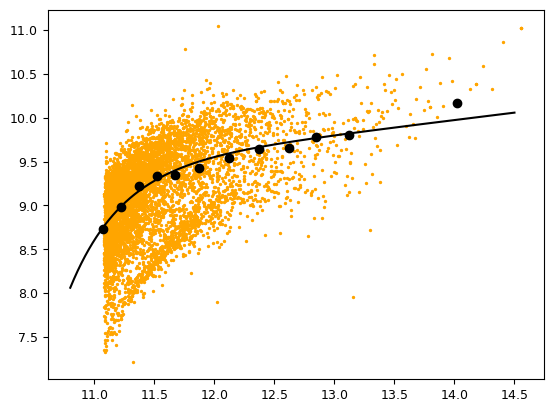

In [44]:
binvalues = [11,11.15,11.3,11.45,11.6,11.75,12.,12.25,12.5,12.75,12.95,13.3,13.8,14.75]
binvalues = [11,11.15,11.3,11.45,11.6,11.75,12.,12.25,12.5,12.75,12.95,13.3,14.75]
median,bc,_,_=cbs(foflogmh,fofmhigrp,'median',bins=binvalues)
poptfof,pcov=curve_fit(hihalomodel,10**bc,10**median,p0=[10**9.4,10**11.03,0.3],maxfev=2000,sigma=comberrlin)
perrfof=np.sqrt(np.diagonal(pcov))

plt.figure()
plt.scatter(foflogmh,fofmhigrp,s=2,color='orange')
plt.plot(bc,median,'ko')
foftx=np.linspace(10.8,14.5,10000)
plt.plot(foftx, np.log10(hihalomodel(10**foftx,*poptfof)),color='k')

plt.show()

In [45]:
print("best fitting logM0: ", np.log10(poptfof[0]), " +/- ", np.log10(poptfof[0])-np.log10(perrfof[0]))
print("best fitting logMmin: ", np.log10(poptfof[1]), " +/- ", np.log10(poptfof[1])-np.log10(perrfof[1]))
print("best fitting alpha: ", poptfof[2], " +/- ", perrfof[2])

best fitting logM0:  9.521471525616363  +/-  0.7860224829766302
best fitting logMmin:  11.300858724570624  +/-  0.8848000458528062
best fitting alpha:  0.16795721727944887  +/-  0.06739883260316207


### Where does the group-integrated HI mass fraction peak?

x-location of peak:  11.44482899461647
upper limit:  11.516975069490629
lower limit:  11.332157484700932


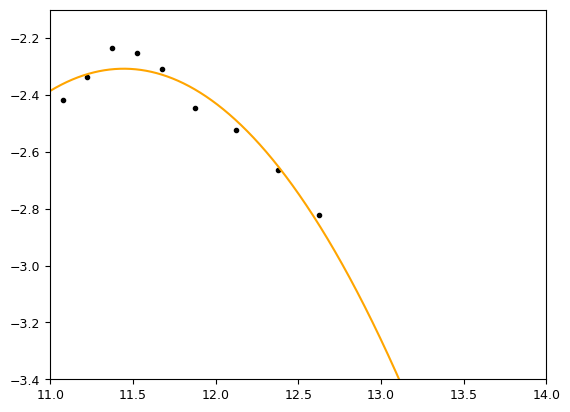

In [47]:
plt.figure()
stopindex=9
plt.plot(binnedfrac.logmh[0:stopindex],binnedfrac.ecofrac[0:stopindex],'k.')
parab = lambda x,a,b,c: a*(x**2)+b*x+c
popt,pcov=curve_fit(parab,binnedfrac.logmh[0:stopindex],binnedfrac.ecofrac[0:stopindex])
perr=np.sqrt(np.diagonal(pcov))
tx=np.linspace(11,14,10000)
modelvals = parab(tx,*popt)
plt.plot(tx,modelvals,color='orange')
plt.xlim(11,14)
plt.ylim(-3.4,-2.1)

print("x-location of peak: ", -popt[1]/(2*popt[0]))
print("upper limit: ", (-popt[1]-perr[1])/(2*(popt[0]-perr[0])))
print("lower limit: ", (-popt[1]+perr[1])/(2*(popt[0]+perr[0])))
plt.show()

## (2) The Scatter of the RESOLVE and ECO HI-Halo Mass Relation

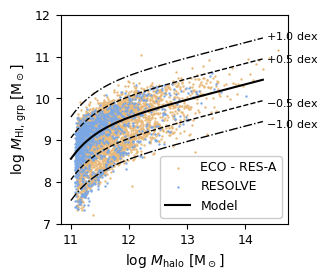

In [48]:
ecologmh=eco.g3logmh_l.to_numpy()
# dyn=eco.g3logmhdyn_l.to_numpy()
# gN=(eco.g3grpngi_l+eco.g3grpndw_l).to_numpy()
# ecologmh[gN>7]=dyn[gN>7]
ecogrpmhi=eco.g3grpmhi_l.to_numpy()
resolvelogmh=resolve.g3logmh_l.to_numpy()
# dyn=resolve.g3logmhdyn_l.to_numpy()
# gN=(resolve.g3grpngi_l+resolve.g3grpndw_l).to_numpy()
# resolvelogmh[gN>7]=dyn[gN>7]
resolvegrpmhi=resolve.g3grpmhi_l.to_numpy()

plt.figure(figsize=(singlecolsize[0],1.4*singlecolsize[1]))
plt.scatter(ecologmh,ecogrpmhi,color=ecoshadecolor,s=0.5,label='ECO - RES-A')
plt.scatter(resolvelogmh,resolvegrpmhi,color=resolveshadecolor,s=0.5, label='RESOLVE')
tx=np.linspace(10**11.,10**14.3,10000)
modelvals=np.log10(hihalomodel(tx,*popthi))
plt.plot(np.log10(tx),modelvals,color='k', label='Model')
plt.plot(np.log10(tx),modelvals-1,color='k',linestyle='-.', linewidth=1)
plt.plot(np.log10(tx),modelvals+1,color='k',linestyle='-.', linewidth=1)
plt.plot(np.log10(tx),modelvals-0.5,color='k',linestyle='--', linewidth=1)
plt.plot(np.log10(tx),modelvals+0.5,color='k',linestyle='--', linewidth=1)
plt.annotate('$+1.0$ dex',xy=(14.35,11.4),fontsize=8)
plt.annotate('$+$0.5 dex',xy=(14.35,10.85),fontsize=8)
plt.annotate('$-$1.0 dex',xy=(14.35,9.3),fontsize=8)
plt.annotate('$-$0.5 dex',xy=(14.35,9.8),fontsize=8)
plt.ylim(7,12)
plt.ylabel(r"log $M_{\rm HI,\, grp}$ [$\rm M_\odot$]")
plt.xlabel(r"log $M_{\rm halo}$ [$\rm M_\odot$]")
plt.legend(loc='lower right', framealpha=1)
plt.tight_layout()
#plt.savefig("../figures/test.pdf",dpi=300)
plt.show()

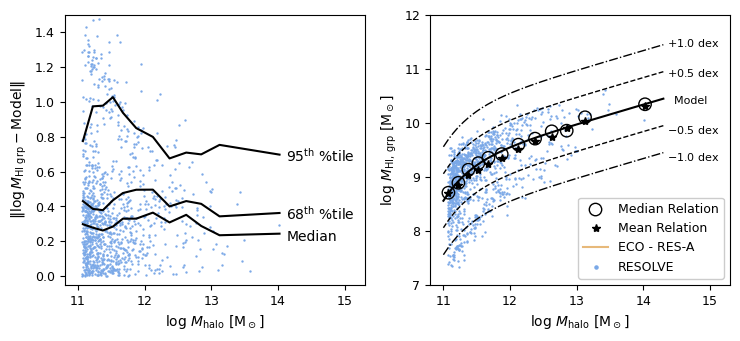

In [49]:
ecologmh=eco.g3logmh_l.to_numpy()
# dyn=eco.g3logmhdyn_l.to_numpy()
# gN=(eco.g3grpngi_l+eco.g3grpndw_l).to_numpy()
# ecologmh[gN>7]=dyn[gN>7]
ecogrpmhi=eco.g3grpmhi_l.to_numpy()
resolvelogmh=resolve.g3logmh_l.to_numpy()
# dyn=resolve.g3logmhdyn_l.to_numpy()
# gN=(resolve.g3grpngi_l+resolve.g3grpndw_l).to_numpy()
# resolvelogmh[gN>7]=dyn[gN>7]
resolvegrpmhi=resolve.g3grpmhi_l.to_numpy()

fig,axs=plt.subplots(ncols=2,figsize=(doublecolsize[0],0.8*doublecolsize[1]))
#axs[1].scatter(ecologmh,ecogrpmhi,color=ecoshadecolor,s=0.5)
axs[1].scatter(resolvelogmh,resolvegrpmhi,color=resolveshadecolor,s=0.5)
kdeplot(ecologmh,y=ecogrpmhi,color=ecoshadecolor,ax=axs[1],zorder=0,levels=7)

tx=np.linspace(10**11.,10**14.3,10000)
modelvals=np.log10(hihalomodel(tx,*popthi))
# axs[1].errorbar(binnedhihm.logmh,binnedhihm.ecomhigrp,yerr=[binnedhihm.ecomhigrp_staterrlo,binnedhihm.ecomhigrp_staterrhi],\
#                markeredgecolor='k',markerfacecolor='None',ls='None',marker='o',markersize=5,label='Median')
axs[1].scatter(binnedhihm.logmh,binnedhihm.ecomhigrp,marker='o',facecolor='None',edgecolor='k',label='Median Relation',s=80)
mean,bc,_,_ = cbs(ecologmh,ecogrpmhi,np.average,bins=binvalues)
axs[1].plot(bc,mean,'k*', label='Mean Relation')
axs[1].plot(np.log10(tx),modelvals,color='k')
axs[1].plot(np.log10(tx),modelvals-1,color='k',linestyle='-.', linewidth=1)
axs[1].plot(np.log10(tx),modelvals+1,color='k',linestyle='-.', linewidth=1)
axs[1].plot(np.log10(tx),modelvals-0.5,color='k',linestyle='--', linewidth=1)
axs[1].plot(np.log10(tx),modelvals+0.5,color='k',linestyle='--', linewidth=1)
axs[1].annotate('$+1.0$ dex',xy=(14.35,11.4),fontsize=8)
axs[1].annotate('$+$0.5 dex',xy=(14.35,10.85),fontsize=8)
axs[1].annotate('  Model', xy=(14.35,10.35),fontsize=8)
axs[1].annotate('$-$1.0 dex',xy=(14.35,9.3),fontsize=8)
axs[1].annotate('$-$0.5 dex',xy=(14.35,9.8),fontsize=8)
axs[1].set_ylim(7,12)
axs[1].plot([12,13],[-99,-98],color=ecoshadecolor,label='ECO - RES-A')
axs[1].scatter(12,-99,color=resolveshadecolor,s=5,label='RESOLVE')
axs[1].set_ylabel(r"log $M_{\rm HI,\, grp}$ [$\rm M_\odot$]")
axs[1].set_xlabel(r"log $M_{\rm halo}$ [$\rm M_\odot$]")
axs[1].legend(loc='lower right', framealpha=1)
axs[1].set_xlim(10.8,15.3)

popthieco_wo_resa=[10**9.427,10**11.292,0.31]
popthiresolve = [10**9.473,10**11.298,0.259]
binvalues = [11,11.15,11.3,11.45,11.6,11.75,12.,12.25,12.5,12.75,12.95,13.3,14.75]
residuals=np.abs(ecogrpmhi - np.log10(hihalomodel(10**ecologmh,*popthieco_wo_resa)))
resresiduals=np.abs(resolvegrpmhi - np.log10(hihalomodel(10**resolvelogmh,*popthi)))
medresid,bc,_,_=cbs(ecologmh,residuals,'median',bins=binvalues)
#axs[0].scatter(ecologmh, residuals,color=ecoshadecolor,s=0.5)
kdeplot(ecologmh,y=residuals,color=ecoshadecolor, ax=axs[0], zorder=0, levels=7)
axs[0].scatter(resolvelogmh,resresiduals,color=resolveshadecolor,s=0.5)
axs[0].plot(bc,medresid,'k')
axs[0].annotate("Median",xy=(max(bc)+0.1,medresid[-1]-0.04))
resid95,bc,_,_=cbs(ecologmh,residuals,lambda x:np.nanpercentile(x,95),bins=binvalues)
axs[0].plot(bc,resid95,color='k')
axs[0].annotate(r"95$^{\rm th}$ %tile",xy=(max(bc)+0.1,resid95[-1]-0.04))
resid68,bc,_,_=cbs(ecologmh,residuals,lambda x:np.nanpercentile(x,68),bins=binvalues)
axs[0].plot(bc,resid68,color='k')
axs[0].annotate(r"68$^{\rm th}$ %tile",xy=(max(bc)+0.1,resid68[-1]-0.04))
axs[0].set_ylim(-0.05,1.5)
axs[0].set_ylabel(r"$\left\|\log M_{\rm HI\,\, grp} - {\rm Model}\right\|$")
axs[0].set_xlabel(r"log $M_{\rm halo}$ [$\rm M_\odot$]")
axs[0].set_xlim(10.8,15.3)
plt.tight_layout()
#plt.savefig("../figures/RESOLVE_ECO_HIHMscatter.pdf",dpi=300)
plt.show()

In [50]:
np.max(np.abs(mean - binnedhihm.ecomhigrp))

0.1290664559187018

In [51]:
below_pt5dex_flag = ecogrpmhi < np.log10(hihalomodel(10**ecologmh,*popthi))+0.5
below_pt5dex_percent = np.sum(below_pt5dex_flag)/len(below_pt5dex_flag)
print(below_pt5dex_percent)

above_mpt5dex_flag = (ecogrpmhi > np.log10(hihalomodel(10**ecologmh,*popthi))-0.5)
above_mpt5dex_percent = np.sum(above_mpt5dex_flag)/len(above_mpt5dex_flag)
print(above_mpt5dex_percent)


0.9490977187606401
0.8215866530473273


In [52]:
ecologmh.shape, residuals.shape
from scipy.stats import ks_2samp
sel1 = (ecologmh<11.5)
sel2 = (ecologmh>11.5)&(ecologmh<12.1)
sel3 = (ecologmh>12.1)&(ecologmh<13.3)
sel4 = (ecologmh>13.3)
print(ks_2samp(residuals[sel1],residuals[sel2],'greater '))
print(ks_2samp(residuals[sel2],residuals[sel3],'greater'))
print(ks_2samp(residuals[sel3],residuals[sel4],'greater'))

KstestResult(statistic=0.11829748234406168, pvalue=4.921528541031779e-15, statistic_location=0.5833994777362008, statistic_sign=1)
KstestResult(statistic=0.006562333864965444, pvalue=0.9564446630059823, statistic_location=0.040920583895866613, statistic_sign=1)
KstestResult(statistic=0.02728920515574651, pvalue=0.9172649931087233, statistic_location=0.029605660263198885, statistic_sign=1)


/tmp/ipykernel_785517/3271637334.py:7: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  print(ks_2samp(residuals[sel1],residuals[sel2],'greater '))
/tmp/ipykernel_785517/3271637334.py:8: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  print(ks_2samp(residuals[sel2],residuals[sel3],'greater'))


## (3) Comparing to Previous Work

In [77]:
import foftools as fof
from center_binned_stats import center_binned_stats as cbs
from smoothedbootstrap import smoothedbootstrap as sbs

In [78]:
# plt.figure(figsize=(singlecolsize[0],singlecolsize[1]*1.5))
# plt.plot()
# tx=np.linspace(11,15,10000)
# #plt.plot(tx,np.log10(hihalomodel(10**tx,*popthi)),color='k',linewidth=1, zorder=98, label='G3')
# plt.errorbar(binnedhihm.logmh,binnedhihm.ecomhigrp,yerr=[binnedhihm.ecomhigrp_staterrlo,binnedhihm.ecomhigrp_staterrhi],\
#              color='k',ls='None',marker='o',markersize=3)
# plt.fill_between(binnedhihm.logmh,binnedhihm.ecomhigrp-binnedhihm.ecomhigrp_syserrlo,binnedhihm.ecomhigrp+binnedhihm.ecomhigrp_syserrhi,\
#                 color='grey')
# # Obuljen 2019
# obuljen_alpha = 0.48
# obuljen_Mmin = 10**(11.18) / 0.7 / fof.getmhoffset(180,337,1,1,6)
# obuljen_M0 = 10**9.44 / 0.7 / fof.getmhoffset(180,337,1,1,6)
# obuljen_params = (obuljen_M0, obuljen_Mmin, obuljen_alpha)
# plt.plot(tx, np.log10(hihalomodel(10**tx,*obuljen_params)), color='red', label='O19',linewidth=1)

# # Guo 2020
# # show guo et al 2020
# guofile = open("TableA1Guo2020.txt", 'r')
# guohalomass = []
# guohimass = []
# guohimasserr = []
# guobins = []
# for line in guofile:
#     if line.startswith('['):
#         split = line.split()
#         binstart = float(split[0][1:-1])
#         binend = float(split[1][:-1])
#         guobins.append(binstart)
#         guohalomass.append((binstart+binend)/2.)
#         guohimass.append(float(split[3]))
#         guohimasserr.append(float(split[5]))
# guobins.append(binend)
# guohimass=np.array(guohimass)
# guohimasserr=np.array(guohimasserr)
# guohalomass = np.log10(10**np.array(guohalomass)/fof.getmhoffset(200,337,1,1,6))
# plt.fill_between(guohalomass,guohimass+guohimasserr,guohimass-guohimasserr,color='green',alpha=0.6,label='G20')

# # show zhang 22
# li = pd.read_csv("Li22xGASS.csv")
# li.loc[:,'Mhalo']=np.log10(10**li.Mhalo / fof.getmhoffset(200,337,1,1,6))
# plt.plot(li.Mhalo,li.Mhi, color='orange', linestyle='dashed', label='L22')

# # show chauhan et al 2020
# c20data = pd.read_csv("Chauhan2020MedianTotalGroupHI.csv")
# c20_logm337 = np.log10(10**c20data.logm200 / fof.getmhoffset(200,337,1,1,6))
# c20_himass = np.array(c20data.mhi)
# plt.plot(c20_logm337, c20_himass, color='blue', linestyle='-.', label='C20*',linewidth=1)

# # show callette 2021
# c21data = pd.read_csv("Callette2021relation.csv") # use Delta=333
# plt.plot(c21data.logDM, c21data.logMHItot, color='purple', linestyle='dotted', label="Ca21*",linewidth=1)
# plt.xlim(11,14)
# plt.ylabel(r"log $M_{\rm HI,\, grp}$ [$\rm M_\odot$]")
# plt.xlabel(r"log $M_{\rm halo}$ [$\rm M_\odot$]")
# plt.ylim(8.3,11.)
# plt.tight_layout()
# plt.legend(loc='upper left',fontsize=8)
# plt.savefig("../figures/HIHMlit.pdf",dpi=300)
# plt.show()

In [79]:
# plt.figure()
# plt.plot()
# tx=np.linspace(11,15,10000)
# #plt.plot(tx,np.log10(hihalomodel(10**tx,*popthi)),color='k',linewidth=1, zorder=98, label='G3')
# plt.errorbar(binnedhihm.logmh,binnedhihm.ecomhigrp,yerr=[binnedhihm.ecomhigrp_staterrlo,binnedhihm.ecomhigrp_staterrhi],\
#              color='k',ls='None',marker='o',markersize=3)
# #plt.fill_between(binnedhihm.logmh,binnedhihm.ecomhigrp-binnedhihm.ecomhigrp_syserrlo,binnedhihm.ecomhigrp+binnedhihm.ecomhigrp_syserrhi,\
# #                color='grey')
# # Obuljen 2019
# obuljen_alpha = 0.48
# obuljen_Mmin = 10**(11.18) / 0.7 / fof.getmhoffset(180,337,1,1,6)
# obuljen_M0 = 10**9.44 / 0.7 / fof.getmhoffset(180,337,1,1,6)
# obuljen_params = (obuljen_M0, obuljen_Mmin, obuljen_alpha)
# plt.plot(tx, np.log10(hihalomodel(10**tx,*obuljen_params)), color='red', label='O19',linewidth=1)

# # Guo 2020
# # show guo et al 2020
# guofile = open("TableA1Guo2020.txt", 'r')
# guohalomass = []
# guohimass = []
# guohimasserr = []
# guobins = []
# for line in guofile:
#     if line.startswith('['):
#         split = line.split()
#         binstart = float(split[0][1:-1])
#         binend = float(split[1][:-1])
#         guobins.append(binstart)
#         guohalomass.append((binstart+binend)/2.)
#         guohimass.append(float(split[3]))
#         guohimasserr.append(float(split[5]))
# guobins.append(binend)
# guohimass=np.array(guohimass)
# guohimasserr=np.array(guohimasserr)
# guohalomass = np.log10(10**np.array(guohalomass)/fof.getmhoffset(200,337,1,1,6))
# plt.fill_between(guohalomass,guohimass+guohimasserr,guohimass-guohimasserr,color='green',alpha=0.6,label='G20')

# # show Li 22
# li = pd.read_csv("Li22xGASS.csv")
# li.loc[:,'Mhalo']=np.log10(10**li.Mhalo / fof.getmhoffset(200,337,1,1,6))
# plt.plot(li.Mhalo,li.Mhi, color='orange', linestyle='dashed', label='L22')

# # show chauhan et al 2020
# c20data = pd.read_csv("Chauhan2020MedianTotalGroupHI.csv")
# c20_logm337 = np.log10(10**c20data.logm200 / fof.getmhoffset(200,337,1,1,6))
# c20_himass = np.array(c20data.mhi)
# plt.plot(c20_logm337, c20_himass, color='blue', linestyle='-.', label='C20*',linewidth=1)

# # show callette 2021
# c21data = pd.read_csv("Callette2021relation.csv") # use Delta=333
# plt.plot(c21data.logDM, c21data.logMHItot, color='purple', linestyle='dotted', label="Ca21*",linewidth=1)
# plt.xlim(11,14)
# plt.ylabel(r"log $M_{\rm HI,\, grp}$ [$\rm M_\odot$]")
# plt.xlabel(r"log $M_{\rm halo}$ [$\rm M_\odot$]")
# plt.ylim(8.3,11.)
# plt.tight_layout()
# plt.legend(loc='upper left',fontsize=8)
# plt.show()

In [80]:
resolve=pd.read_csv("../resolve_and_eco/RESOLVEdata_G3catalog_luminosity.csv")
resolve.loc[:,'abovefloor']=((resolve.f_a==1)&(resolve.absrmag<=-17.33))|((resolve.f_b==1)&(resolve.absrmag<=-17.0))
resolve=resolve[(resolve.g3grpcz_l>4500)&(resolve.g3grpcz_l<7000)&(resolve.abovefloor)&(resolve.g3fc_l==1)]
eco=pd.read_csv("../resolve_and_eco/ECOdata_G3catalog_luminosity.csv")
eco=eco[(eco.g3grpcz_l>3000)&(eco.g3grpcz_l<7000)&(eco.absrmag<-17.33)&(eco.g3fc_l==1)&(eco.vif<1)]
binnedhihm = pd.read_csv("resolve_eco_hihm_updated052023.csv")

#ecofof = pd.read_csv("/srv/two/cielo/zhutchen/database/make_ECO_DR3/ECODR3_Feb2023.csv")
#ecofof = ecofof[(ecofof.grpcz>3000)&(ecofof.grpcz<7000)&(ecofof.absrmag<-17.33)&(ecofof.fc>0)&(ecofof.dup<1)]

/tmp/ipykernel_785517/238459941.py:4: DtypeWarning: Columns (70,83) have mixed types. Specify dtype option on import or set low_memory=False.
  eco=pd.read_csv("../resolve_and_eco/ECOdata_G3catalog_luminosity.csv")


In [81]:
reslogmhhybrid = resolve.g3logmh_l.to_numpy()
# dyn=resolve.g3logmhdyn_l.to_numpy()
# gN=(resolve.g3grpngi_l+resolve.g3grpndw_l).to_numpy()
# reslogmhhybrid[gN>7]=dyn[gN>7]
resolve.loc[:,'g3logmh_hybrid_l']=reslogmhhybrid

ecologmhhybrid = eco.g3logmh_l.to_numpy()
# dyn=eco.g3logmhdyn_l.to_numpy()
# gN=(eco.g3grpngi_l+eco.g3grpndw_l).to_numpy()
# ecologmhhybrid[gN>7]=dyn[gN>7]
eco.loc[:,'g3logmh_hybrid_l']=ecologmhhybrid

#ecofoflogmhhybrid = ecofof.logmhvir.to_numpy()
# dyn = ecofof.logmhdyn.to_numpy()
# gN=(ecofof.grpn).to_numpy()
# ecofoflogmhhybrid[gN>7]=dyn[gN>7]
#ecofof.loc[:,'logmh_hybrid']=ecofoflogmhhybrid

In [82]:
ecoresb = pd.concat([eco,resolve[resolve.f_b==1]])
assert len(ecoresb)<(len(eco)+len(resolve))

In [83]:
binvalues = [11,11.15,11.3,11.45,11.6,11.75,12.,12.25,12.5,12.75,12.95,13.3,14.75]
grpmhi = ecoresb.g3grpmhi_l.to_numpy()
logmh = ecoresb.g3logmh_hybrid_l.to_numpy()
mediangrpmhi,binc,_,_=cbs(logmh,grpmhi,'median',bins=binvalues)
errlo,errhi=np.zeros_like(mediangrpmhi),np.zeros_like(mediangrpmhi)
for ii in range(0,len(binvalues)-1): 
    datasel = np.where((logmh>binvalues[ii])&(logmh<binvalues[ii+1]))
    dist_of_medians = sbs(grpmhi[datasel], 5000, lambda x: np.median(x,axis=1))
    ptiles = np.percentile(dist_of_medians, (16,84))
    errlo[ii]=ptiles[0]
    errhi[ii]=ptiles[1]
errlo =  mediangrpmhi - errlo
errhi = -mediangrpmhi + errhi

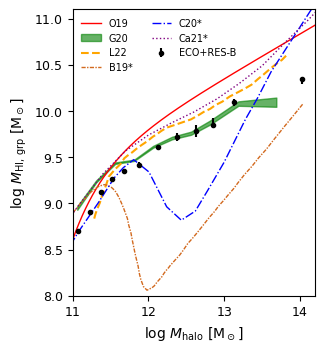

In [84]:
plt.figure(figsize=(singlecolsize[0],singlecolsize[1]*1.75))
plt.plot()
tx=np.linspace(11,15,10000)
#plt.plot(tx,np.log10(hihalomodel(10**tx,*popthi)),color='k',linewidth=1, zorder=98, label='G3')
plt.errorbar(binc,mediangrpmhi,yerr=[errlo,errhi],\
             color='k',ls='None',marker='o',markersize=3, label='ECO+RES-B')
# Obuljen 2019
obuljen_alpha = 0.48
obuljen_Mmin = 10**(11.18) / 0.7 / fof.getmhoffset(180,337,1,1,6)
obuljen_M0 = 10**9.44 / 0.7 / fof.getmhoffset(180,337,1,1,6)
obuljen_params = (obuljen_M0, obuljen_Mmin, obuljen_alpha)
plt.plot(tx, np.log10(hihalomodel(10**tx,*obuljen_params)), color='red', label='O19',linewidth=1)

# Guo 2020
# show guo et al 2020
guofile = open("TableA1Guo2020.txt", 'r')
guohalomass = []
guohimass = []
guohimasserr = []
guobins = []
for line in guofile:
    if line.startswith('['):
        split = line.split()
        binstart = float(split[0][1:-1])
        binend = float(split[1][:-1])
        guobins.append(binstart)
        guohalomass.append((binstart+binend)/2.)
        guohimass.append(float(split[3]))
        guohimasserr.append(float(split[5]))
guobins.append(binend)
guohimass=np.array(guohimass)
guohimasserr=np.array(guohimasserr)
guohalomass = np.log10(10**np.array(guohalomass)/fof.getmhoffset(200,337,1,1,6))
plt.fill_between(guohalomass,guohimass+guohimasserr,guohimass-guohimasserr,color='green',alpha=0.6,label='G20')

# show Li 22
li = pd.read_csv("Li22xGASS.csv")
li.loc[:,'Mhalo']=np.log10(10**li.Mhalo / fof.getmhoffset(200,337,1,1,6))
plt.plot(li.Mhalo,li.Mhi, color='orange', linestyle='dashed', label='L22')

# plot Baugh 19
b19 = pd.read_csv("Baugh19_HIHM.csv")
b19 = b19.sort_values(by='logMhalo_heq1')
b19logmh = b19.logMhalo_heq1-np.log10(0.7)
b19logmhi = b19.logMHI_heq1-np.log10(0.7)
plt.plot(b19logmh,b19logmhi,linewidth=1,color='chocolate',linestyle=(0,(3,1,1,1)), label='B19*')


# show chauhan et al 2020
c20data = pd.read_csv("Chauhan2020MedianTotalGroupHI.csv")
c20_logm337 = np.log10(10**c20data.logm200 / fof.getmhoffset(200,337,1,1,6))
c20_himass = np.array(c20data.mhi)
plt.plot(c20_logm337, c20_himass, color='blue', linestyle='-.', label='C20*',linewidth=1)

# show callette 2021
c21data = pd.read_csv("Callette2021relation.csv") # use Delta=333
plt.plot(c21data.logDM, c21data.logMHItot, color='purple', linestyle='dotted', label="Ca21*",linewidth=1)

# plot Z21
# def z21_hihm(logmhalo,z): # everything in h=1 units
#     a = 0.78-0.030*z
#     b = -0.23 + 0.68*z
#     c = 0.92 - 0.32*z
#     d = 11 + 0.038*z
#     f = 0.79 + 0.18*z
#     mhalo = 10**logmhalo
#     logmhi = a*logmhalo + b + c*np.exp(-1/f**2. * (logmhalo-d)**2.)
#     return logmhi # in h=1 units
# plt.plot(tx, z21_hihm(tx+np.log10(0.7),0)-np.log10(0.7),color='gray',linestyle=(5,(10,3)),zorder=0,label='Z21*')

plt.xlim(11,14.2)
plt.ylabel(r"log $M_{\rm HI,\, grp}$ [$\rm M_\odot$]")
plt.xlabel(r"log $M_{\rm halo}$ [$\rm M_\odot$]")
plt.ylim(8,11.1)
plt.tight_layout()
plt.legend(loc='upper left',fontsize=7,ncol=2,framealpha=0)


plt.savefig("../figures/HIHMlit_new.pdf",dpi=300)
plt.show()

In [61]:
errhi

array([0.01327413, 0.01152583, 0.0175101 , 0.02319071, 0.02158859,
       0.03333561, 0.02893907, 0.03973819, 0.05762742, 0.08433366,
       0.03115996, 0.02006574])

In [62]:
pd.read_csv("resolve_eco_hihm.csv").ecomhigrp_syserrhi

0     0.137600
1     0.115200
2     0.118095
3     0.110000
4     0.087600
5     0.057276
6     0.122224
7     0.089856
8     0.109491
9     0.081609
10    0.058565
11    0.128321
Name: ecomhigrp_syserrhi, dtype: float64

# What happens if I do it with ECO only using galaxies detected in ALFALFA?

/tmp/ipykernel_2841080/1550841199.py:9: DtypeWarning: Columns (71,84) have mixed types. Specify dtype option on import or set low_memory=False.
  ecodata = pd.read_csv("../resolve_and_eco/ECOdata_G3catalog_luminosity.csv")


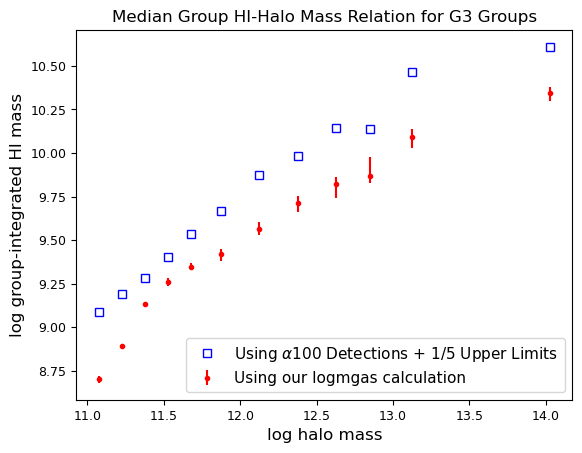

In [65]:
%matplotlib inline
plt.figure()
plt.plot()
tx=np.linspace(11,15,10000)
plt.errorbar(binnedhihm.logmh,binnedhihm.ecomhigrp,yerr=[binnedhihm.ecomhigrp_staterrlo,binnedhihm.ecomhigrp_staterrhi],\
             color='red',ls='None',marker='o',markersize=3, label='Using our logmgas calculation')

# now try simulating Guo - first throw away some halos with mass < 11.5
ecodata = pd.read_csv("../resolve_and_eco/ECOdata_G3catalog_luminosity.csv")
ecodata = ecodata[(ecodata.g3grpcz_l<7000)&(ecodata.g3grpcz_l>3000)&(ecodata.absrmag<-17.33)]
ecodata = ecodata[(ecodata.mhidet_a100>0)]#|(ecodata.mhilim_a100>0)]
#mhisim = 10**ecodata.logmgas/1.4 # just for testing
mhisim = ecodata.mhidet_a100 + (1/5.)*ecodata.mhilim_a100
ecodata.loc[:,'mhisim'] = mhisim
mhigrpsim = ic.get_int_mass(np.log10(ecodata.mhisim.to_numpy()), ecodata.g3grp_l.to_numpy())
ecodata.loc[:,'mhigrpsim'] = mhigrpsim

ecodata = ecodata[ecodata.g3fc_l>0]
medianmhigrpsim,bincenters,_,_=cbs(ecodata.g3logmh_l.to_numpy(),ecodata.mhigrpsim.to_numpy(),'median',bins=binvalues)
plt.plot(bincenters,medianmhigrpsim,'s',markerfacecolor='None',markeredgecolor='blue',label=r'Using $\alpha$100 Detections + 1/5 Upper Limits')
plt.legend(loc='lower right',fontsize=11)
plt.ylabel("log group-integrated HI mass",fontsize=12)
plt.xlabel('log halo mass',fontsize=12)
plt.title("Median Group HI-Halo Mass Relation for G3 Groups")
plt.show()

9.124356403476344
9.098111292287284


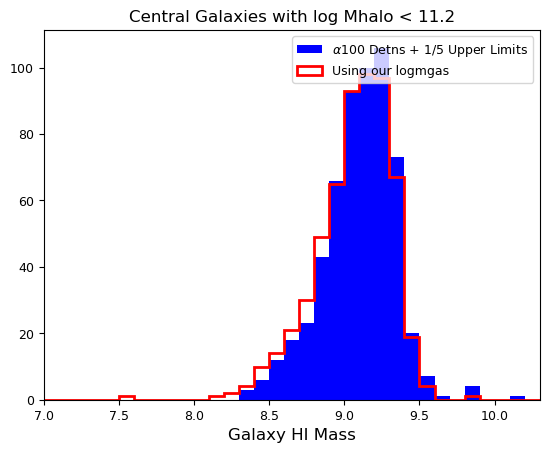

In [66]:
plt.figure()
sel = (ecodata.g3logmh_l<11.2)
binv = np.arange(7,11,0.1)
plt.hist(np.log10(ecodata[sel].mhisim),color='blue',bins=binv,label=r'$\alpha$100 Detns + 1/5 Upper Limits')
print(np.median(np.log10(ecodata[sel].mhisim)))
print(np.median(np.log10(10**ecodata[sel].logmgas/1.4)))
plt.hist(np.log10(10**ecodata[sel].logmgas/1.4),color='red',histtype='step',bins=binv,linewidth=2,label='Using our logmgas')
plt.title("Central Galaxies with log Mhalo < 11.2")
plt.legend(loc='best')
plt.xlabel("Galaxy HI Mass", fontsize=12)
plt.legend(loc='upper right')
plt.xlim(7,10.3)
plt.show()

In [67]:
medianmhigrpsim - binnedhihm.ecomhigrp, np.median(medianmhigrpsim - binnedhihm.ecomhigrp)

(0     0.386038
 1     0.303178
 2     0.152464
 3     0.141828
 4     0.186072
 5     0.246987
 6     0.310851
 7     0.267668
 8     0.319952
 9     0.272116
 10    0.374848
 11    0.263982
 Name: ecomhigrp, dtype: float64,
 0.2698920491774981)

In [68]:
medianmhigrpsim

array([ 9.08804092,  9.19340323,  9.28419568,  9.40180088,  9.53443687,
        9.66535019,  9.87624973,  9.98229817, 10.14064568, 10.13745146,
       10.4643791 , 10.60871366])

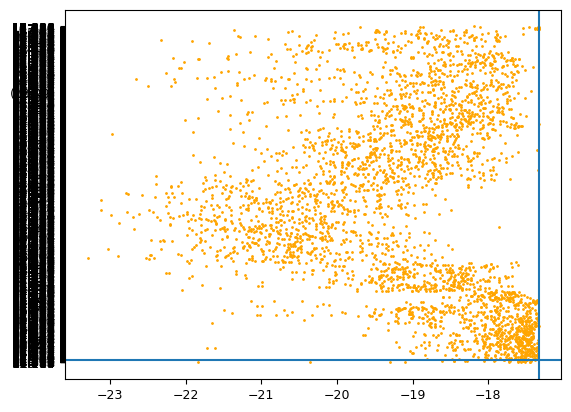

In [69]:
plt.figure()
plt.scatter(ecodata.absrmag,ecodata.rmag,s=1,color='orange')
plt.axvline(-17.33)
plt.axhline(17.77)
plt.show()

/tmp/ipykernel_2841080/3932511964.py:9: DtypeWarning: Columns (71,84) have mixed types. Specify dtype option on import or set low_memory=False.
  ecodata = pd.read_csv("../resolve_and_eco/ECOdata_G3catalog_luminosity.csv")


TypeError: '<' not supported between instances of 'str' and 'float'

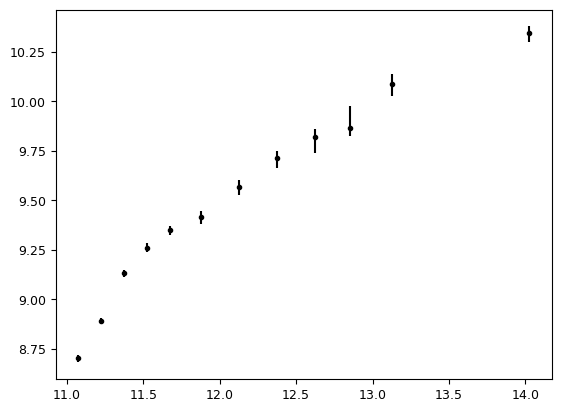

In [70]:
%matplotlib inline
plt.figure()
plt.plot()
tx=np.linspace(11,15,10000)
plt.errorbar(binnedhihm.logmh,binnedhihm.ecomhigrp,yerr=[binnedhihm.ecomhigrp_staterrlo,binnedhihm.ecomhigrp_staterrhi],\
             color='k',ls='None',marker='o',markersize=3, label='G3 Group HI-Halo Mass Relation')

# now try simulating Guo - first throw away some halos with mass < 11.5
ecodata = pd.read_csv("../resolve_and_eco/ECOdata_G3catalog_luminosity.csv")
ecodata = ecodata[ecodata.rmag<17.77]
#ecodata=ecodata[(ecodata.mhidet_a100>0)|(ecodata.mhilim_a100>0)]
#ecodata = ecodata[(ecodata.g3grpcz_l<7000)&(ecodata.g3grpcz_l>3000)&(ecodata.absrmag<-17.33)]

lowmassindex = ecodata[ecodata.absrmag>-18.8].index.to_numpy()
pcent=0.05
discardindex = np.random.choice(lowmassindex, int(pcent*len(lowmassindex)), replace=False)
ecodata.drop(index=discardindex, inplace=True)

mhigrpsim = ic.get_int_mass(np.log10(10**ecodata.logmgas.to_numpy()/1.4), ecodata.g3grp_l.to_numpy())
mhigrpsim = ic.get_int_mass(np.log10(ecodata.mhidet_a100.to_numpy()+ecodata.mhilim_a100.to_numpy()), ecodata.g3grp_l.to_numpy())
medianmhigrpsim,bincenters,_,_=cbs(ecodata.g3logmh_l.to_numpy(),mhigrpsim,'median',bins=binvalues)

# Guo 2020
# show guo et al 2020
guofile = open("TableA1Guo2020.txt", 'r')
guohalomass = []
guohimass = []
guohimasserr = []
guobins = []
for line in guofile:
    if line.startswith('['):
        split = line.split()
        binstart = float(split[0][1:-1])
        binend = float(split[1][:-1])
        guobins.append(binstart)
        guohalomass.append((binstart+binend)/2.)
        guohimass.append(float(split[3]))
        guohimasserr.append(float(split[5]))
guobins.append(binend)
guohimass=np.array(guohimass)
guohimasserr=np.array(guohimasserr)
guohalomass = np.log10(10**np.array(guohalomass)/fof.getmhoffset(200,337,1,1,6))
plt.fill_between(guohalomass,guohimass+guohimasserr,guohimass-guohimasserr,color='green',alpha=0.6,label='G20')

plt.plot(bincenters,medianmhigrpsim,'s',markerfacecolor='None',markeredgecolor='blue',label='G3 Groups + ALFALFA-100 Detections')
plt.legend(loc='upper left',fontsize=12)
plt.ylabel("log group-integrated HI mass",fontsize=12)
plt.xlabel('log halo mass',fontsize=12)
plt.title("")
plt.show()

In [ ]:
medianmhigrpsim - binnedhihm.ecomhigrp, np.median(medianmhigrpsim - binnedhihm.ecomhigrp)

# Table of Best-Fitting Models for Different Samples 

In [63]:
%reset -f

In [64]:
def hihalomodel(Mh, M0, Mmin, alpha):
    return M0*((Mh/Mmin)**alpha)*np.exp(-1*Mmin/Mh)

import sys
sys.path.insert(0,'../g3algo/')
import numpy as np
import pandas as pd
import matplotlib
#matplotlib.use('TkAgg')
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, AutoLocator
from matplotlib import rcParams
from scipy.optimize import curve_fit
from scipy.stats import chisquare
import foftools as fof
import iterativecombination as ic
from center_binned_stats import center_binned_stats as cbs
from smoothedbootstrap import smoothedbootstrap as sbs
rcParams['axes.labelsize'] = 9
rcParams['xtick.labelsize'] = 9
rcParams['ytick.labelsize'] = 9
rcParams['legend.fontsize'] = 9
rcParams['font.family'] = 'sans-serif'
rcParams['grid.color'] = 'k'
rcParams['grid.linewidth'] = 0.2
my_locator = MaxNLocator(6)
singlecolsize = (3.3522420091324205, 2.0717995001590714)
doublecolsize = (7.500005949910059, 4.3880449973709)

In [65]:
resolve=pd.read_csv("../resolve_and_eco/RESOLVEdata_G3catalog_luminosity.csv")
resolve.loc[:,'abovefloor'] = ((resolve.f_a==1)&(resolve.absrmag<=-17.33))|((resolve.f_b==1)&(resolve.absrmag<=-17.0))
resolve=resolve[(resolve.g3grpcz_l>4500)&(resolve.g3grpcz_l<7000)&(resolve.abovefloor)&(resolve.g3fc_l==1)]
eco=pd.read_csv("../resolve_and_eco/ECOdata_G3catalog_luminosity.csv")
eco=eco[(eco.g3grpcz_l>=3000)&(eco.g3grpcz_l<=7000)&(eco.absrmag<=-17.33)&(eco.g3fc_l==1)&(eco.vif<1)]
#binnedhihm = pd.read_csv("resolve_eco_hihm.csv")

ecofof = pd.read_csv("../resolve_and_eco/ECOdata_G3catalog_luminosity.csv")
ecofof.loc[:,'grpmhitest']=ic.get_int_mass(np.log10(10**ecofof.logmgas/1.4),ecofof.fofgrp)
ecofof = ecofof[(ecofof.fofgrpcz>=3000)&(ecofof.fofgrpcz<=7000)&(ecofof.absrmag<=-17.33)&(ecofof.foffc>0)]#&(ecofof.dup<1)]
#ecofof=pd.read_csv("../resolve_and_eco/ECOdata_G3catalog_luminosity.csv")
#fofmhigrp = ic.get_int_mass(np.log10(10**ecofof.logmgas/1.4),ecofof.grp)
#ecofof.loc[:,'fofmhigrp']=fofmhigrp
#ecofof=ecofof[(ecofof.grpcz>3000)&(ecofof.grpcz<7000)&(ecofof.absrmag<-17.33)&(ecofof.fc==1)]#&(ecofof.resname=='notinresolve')]

/tmp/ipykernel_785517/3900414288.py:4: DtypeWarning: Columns (70,83) have mixed types. Specify dtype option on import or set low_memory=False.
  eco=pd.read_csv("../resolve_and_eco/ECOdata_G3catalog_luminosity.csv")
/tmp/ipykernel_785517/3900414288.py:8: DtypeWarning: Columns (70,83) have mixed types. Specify dtype option on import or set low_memory=False.
  ecofof = pd.read_csv("../resolve_and_eco/ECOdata_G3catalog_luminosity.csv")


In [66]:
reslogmhhybrid = resolve.g3logmh_l.to_numpy()
# dyn=resolve.g3logmhdyn_l.to_numpy()
# gN=(resolve.g3grpngi_l+resolve.g3grpndw_l).to_numpy()
# reslogmhhybrid[gN>7]=dyn[gN>7]
resolve.loc[:,'g3logmh_hybrid_l']=reslogmhhybrid

ecologmhhybrid = eco.g3logmh_l.to_numpy()
# dyn=eco.g3logmhdyn_l.to_numpy()
# gN=(eco.g3grpngi_l+eco.g3grpndw_l).to_numpy()
# ecologmhhybrid[gN>7]=dyn[gN>7]
eco.loc[:,'g3logmh_hybrid_l']=ecologmhhybrid

ecofoflogmhhybrid = ecofof.foflogmhvir.to_numpy()
# dyn = ecofof.logmhdyn.to_numpy()
# gN=(ecofof.grpn).to_numpy()
# ecofoflogmhhybrid[gN>7]=dyn[gN>7]
ecofof.loc[:,'logmh_hybrid']=ecofoflogmhhybrid

In [67]:
ecoresb = pd.concat([eco,resolve[resolve.f_b==1]])
assert len(ecoresb)<(len(eco)+len(resolve))

In [68]:
resolvefof = pd.read_csv('/srv/two/cielo/zhutchen/database/make_RESOLVE_DR4/RESOLVEliving_051223_updatedfofgroups.csv')
resolvefof.loc[:,'abovefloor'] = ((resolvefof.f_a==1)&(resolvefof.absrmag<=-17.33))|((resolvefof.f_b==1)&(resolvefof.absrmag<=-17.0))
resolvefof = resolvefof[(resolvefof.fofgrpcz>4500)&(resolvefof.fofgrpcz<7000)&(resolvefof.abovefloor)].groupby('fofgrp').first()
ecoresbfof = pd.concat([ecofof,resolvefof[resolvefof.f_b==1]])
assert len(ecoresbfof)<(len(ecofof)+len(resolvefof))

In [69]:
len(ecoresb),len(ecoresbfof)

(6949, 7142)

In [70]:
# first entry = df sample, second entry = True/False whether to fit with systematic errors
samples=dict({
    "ECO+RES-B":[ecoresb[['g3logmh_l','g3grpmhi_l']]],
    "ECO--RES-A": [eco[eco.resname=='notinresolve'][['g3logmh_l','g3grpmhi_l']]],
    "Full RES": [resolve[['g3logmh_l','g3grpmhi_l']]],
    "Full ECO":[eco[['g3logmh_l','g3grpmhi_l']]],
#     "ECO+RES-B (Hybrid Masses)":[ecoresb[['g3logmh_hybrid_l','g3grpmhi_l']]],
#     "ECO--RES-A (Hybrid Masses)": [eco[eco.resname=='notinresolve'][['g3logmh_hybrid_l','g3grpmhi_l']]],
#     "Full RES (Hybrid Masses)": [resolve[['g3logmh_hybrid_l','g3grpmhi_l']]],
#     "Full ECO (Hybrid Masses)":[eco[['g3logmh_hybrid_l','g3grpmhi_l']]],
    "ECO+RES-B -- FoF": [ecoresbfof[['foflogmhvir','fofgrpmhi']]],
    "ECO-RES-A -- FoF": [ecofof[ecofof.resname=='notinresolve'][['logmh_hybrid','fofgrpmhi']]],
    "Full RES -- FoF": [resolvefof[['foflogmhvir','fofgrpmhi']]],
    "Full ECO -- FoF": [ecofof[['logmh_hybrid','fofgrpmhi']]],
})

In [71]:
binvalues = [11,11.15,11.3,11.45,11.6,11.75,12.,12.25,12.5,12.75,12.95,13.3,14.75]
def process_sample(samp, showplots=False):
    df = samp[0]
    grpmhi = df.iloc[:,1].to_numpy()
    logmh = df.iloc[:,0].to_numpy()
    mediangrpmhi,binc,_,_=cbs(logmh,grpmhi,'median',bins=binvalues)
    errlo,errhi=[],[]
    for ii in range(0,len(binvalues)-1): 
        datasel = np.where((logmh>binvalues[ii])&(logmh<binvalues[ii+1]))
        dist_of_medians = sbs(grpmhi[datasel], 5000, lambda x: np.median(x,axis=1))
        ptiles = np.percentile(dist_of_medians, (16,84))
        errlo.append(mediangrpmhi[ii]-ptiles[0])
        errhi.append(ptiles[1]-mediangrpmhi[ii])
    errhi,errlo = np.array(errhi),np.array(errlo)
    weights = (errhi+errlo)/2. # these in are in dex
    weights_linspace = 10**(mediangrpmhi) - 10**(mediangrpmhi-weights)
    
    guess=[10**9.4,10**11.03,0.3]#[1.689e9, 1.2698e11, 3.686e-1]
    popthi,pcov=curve_fit(hihalomodel, 10**binc, 10**mediangrpmhi,\
            sigma=weights_linspace, absolute_sigma=False, p0=guess, maxfev=2000)
    perrhi=np.sqrt(np.diagonal(pcov))
    perrhi[0] = np.log10(popthi[0])-np.log10(perrhi[0])
    perrhi[1] = np.log10(popthi[1])-np.log10(perrhi[1])
    scatter = np.median(np.abs(grpmhi - np.log10(hihalomodel(10**logmh,*popthi))))
    
    plt.figure()
    plt.errorbar(binc, mediangrpmhi, yerr=1*weights, color='k', marker='o', ls='None', markersize=5)
    tx = 10**np.linspace(11,14.5,int(1e4))
    plt.plot(np.log10(tx), np.log10(hihalomodel(tx,*popthi)),'k')
    plt.ylim(7,11.5)
    plt.show()
    outdata = [binc,mediangrpmhi,weights]
    return popthi, perrhi, scatter, outdata

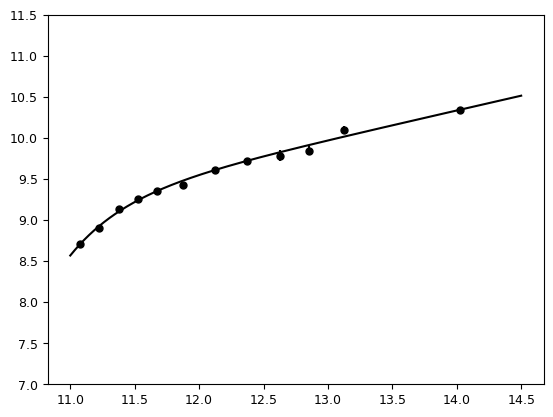

ECO+RES-B


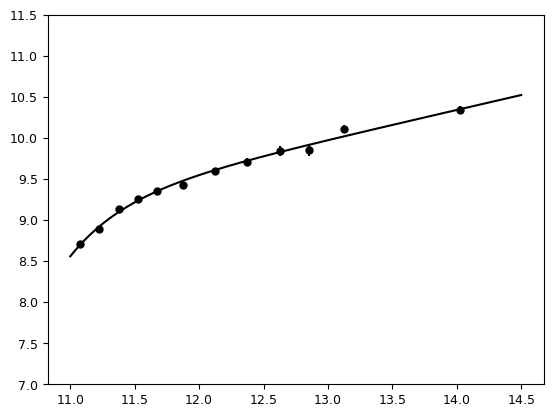

ECO--RES-A


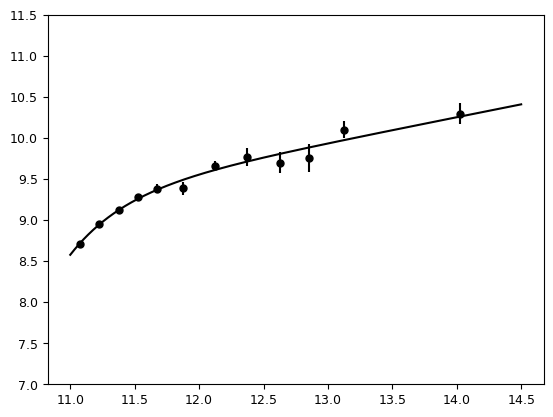

Full RES


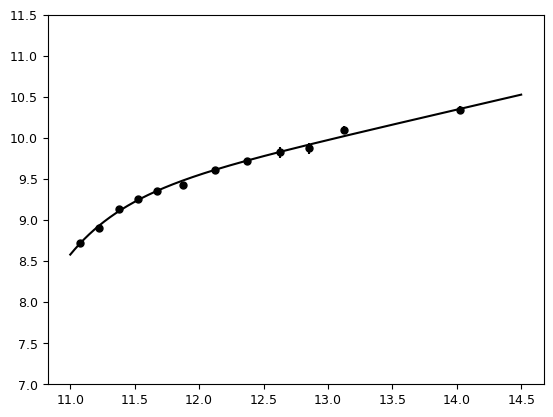

Full ECO


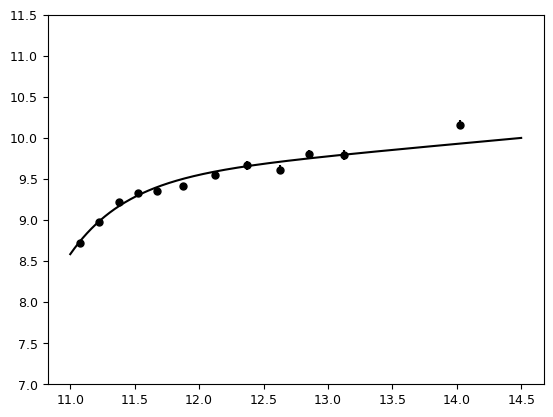

ECO+RES-B -- FoF


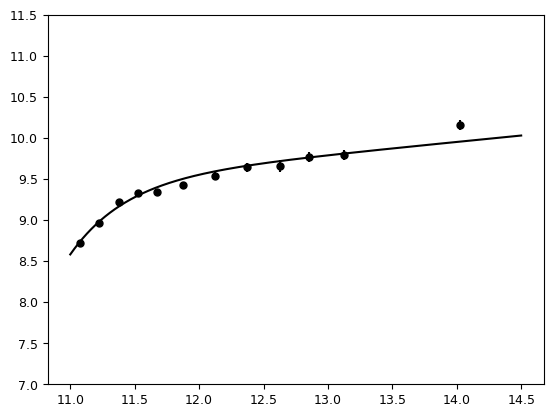

ECO-RES-A -- FoF


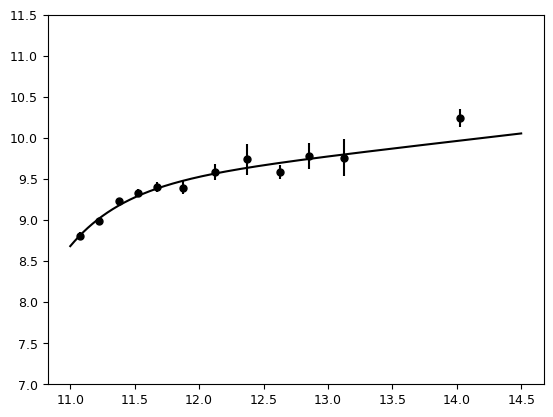

Full RES -- FoF


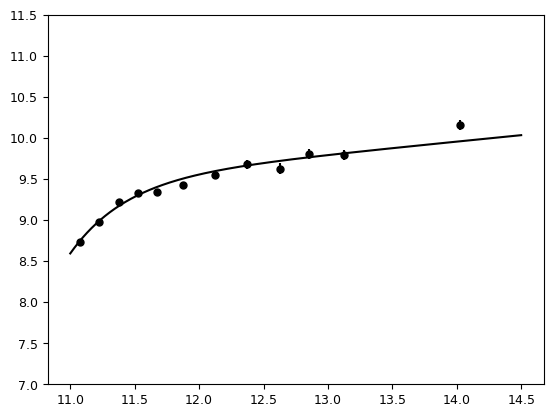

Full ECO -- FoF


In [72]:
%matplotlib inline
bestfitvals = dict({})
mediangrphidata = dict({})
for kk in samples.keys():
    # need function that spits out best fit params and errors, shows each plot for quality check
    popthi, perrhi, sc, data = process_sample(samples[kk])
    bestfitvals[kk] = [np.log10(popthi[0]),perrhi[0],np.log10(popthi[1]),perrhi[1],popthi[2],perrhi[2], sc]
    mediangrphidata[kk] = data
    print(kk)

In [73]:
table = pd.DataFrame.from_dict(bestfitvals, orient='index')
table=table.rename_axis('Sample')
table.columns = [r'$M_0$',r'$\Delta M_0$',r'$M_{\rm min}$',r'$\Delta M_{\rm min}$',r'$\alpha$',r'$\Delta\alpha$','Scatter']
print(table)

                     $M_0$  $\Delta M_0$  $M_{\rm min}$  $\Delta M_{\rm min}$  \
Sample                                                                          
ECO+RES-B         9.329455      1.000448      11.200884              1.103983   
ECO--RES-A        9.328296      0.957197      11.205079              1.058053   
Full RES          9.385429      0.786101      11.229715              0.885476   
Full ECO          9.322156      1.009423      11.190713              1.107888   
ECO+RES-B -- FoF  9.543593      0.833275      11.322739              0.956815   
ECO-RES-A -- FoF  9.536072      0.833194      11.319247              0.957867   
Full RES -- FoF   9.457848      0.659492      11.228141              0.724746   
Full ECO -- FoF   9.536151      0.850048      11.313695              0.964064   

                  $\alpha$  $\Delta\alpha$   Scatter  
Sample                                                
ECO+RES-B         0.359007        0.022828  0.296816  
ECO--RES-A        0.3622

In [74]:
table=table.round(3)

In [75]:
table.to_latex("samples_HIHM_table_updated072723.txt")

/tmp/ipykernel_785517/2838262457.py:1: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  table.to_latex("samples_HIHM_table_updated072723.txt")


10.513641817265363
9.999440445111038


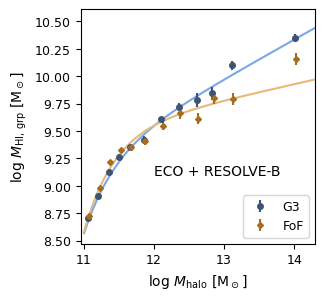

In [76]:
plt.figure(figsize=(singlecolsize[0],singlecolsize[1]*1.5))
tx = np.linspace(11,14.5,int(1e4))
#plotkeys = ['Full RES', 'Full ECO','Full ECO -- FoF']
plotkeys = ['ECO+RES-B','ECO+RES-B -- FoF']
labels=['G3','FoF']
offsets=[-0.02,0,0.02]

resolveshadecolor='#7AA8E7'
resolvemarkercolor='#3D5473'
ecoshadecolor='#E7B97A'
ecomarkercolor='#a66d1e'

colors=[resolvemarkercolor,ecomarkercolor,'k']
linecolors=[resolveshadecolor,ecoshadecolor,'gray']
markertypes=['o','D']
markersizes=[4,3]
for ii,kk in enumerate(plotkeys):
    yval = np.log10(hihalomodel(10**tx,10**bestfitvals[kk][0],10**bestfitvals[kk][2],\
                                    bestfitvals[kk][4]))
    plt.errorbar(mediangrphidata[kk][0]+offsets[ii],mediangrphidata[kk][1],yerr=mediangrphidata[kk][2],
                 ls='None',markersize=markersizes[ii],marker=markertypes[ii],color=colors[ii], label=labels[ii])
    plt.plot(tx, yval, color=linecolors[ii],alpha=1,zorder=0)
    print(max(yval))
plt.xlim(10.95,14.3)
plt.legend(loc='lower right')
plt.xlabel(r"log $M_{\rm halo}$ [${\rm M_\odot}$]")
plt.ylabel(r"log $M_{\rm HI,\,grp}$ [${\rm M_\odot}$]")
plt.annotate('ECO + RESOLVE-B', xy=(12,9.1))
plt.tight_layout()
plt.savefig("../figures/HIHMfits.pdf",dpi=300)
plt.show()

# Does it make a difference if we ccb_remapped?

In [ ]:
dr3 = pd.read_csv("/srv/two/cielo/zhutchen/database/make_ECO_DR3/ECODR3_Jul0822.csv")
dr3 = dr3[(dr3.g3grpcz>2530)&(dr3.g3grpcz<7470)&(dr3.absrmag<=17.33)]
dr3=dr3.groupby('g3grp').first()

In [ ]:
g3grpmhi = dr3.g3grpmhi.to_numpy()
g3grpmhi_ccb = np.log10(dr3.ccb_remapped.to_numpy() * (10**dr3.g3grpmhi.to_numpy()))
dr3.loc[:,'g3grpmhi_ccb']=g3grpmhi_ccb

In [ ]:
dr3[['g3grpmhi','ccb_remapped','g3grpmhi_ccb']][dr3.ccb_remapped>1]

In [ ]:
samples=dict({
    'regular':[dr3[['g3logmhvir','g3grpmhi']]],
    'ccb':[dr3[['g3logmhvir','g3grpmhi_ccb']]]
})
for kk in samples.keys():
    # need function that spits out best fit params and errors, shows each plot for quality check
    popthi, perrhi, sc, data = process_sample(samples[kk])
    print(popthi,perrhi,sc)
    print('---')